# Step 4. Walk-Forward 백테스팅

**Walk-Forward 분석**은 "시험 문제를 미리 보지 않고 공부"하는 것과 같은 원리입니다.

- **In-Sample (IS)**: 과거 24개월 데이터로 최적 포트폴리오 가중치를 학습합니다.
- **Out-of-Sample (OOS)**: 학습에 사용하지 않은 직후 3개월 데이터에 적용하여 실제 성과를 측정합니다.
- 윈도우를 OOS 기간(3개월)씩 슬라이딩하며 반복합니다.

이 방식은 **과적합(overfitting) 위험을 최소화**하고, 전략이 미래에도 작동하는지 현실적으로 검증할 수 있습니다.

| 파라미터 | 값 |
|---|---|
| IS 기간 | 24개월 |
| OOS 기간 | 3개월 |
| 거래비용 (cost_bps) | 10 bps |
| 슬리피지 (slip_bps) | 5 bps |
| **총 편도 비용** | **15 bps** |

In [1]:
# ── Imports & Data Loading ──
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

IMG = Path('images'); IMG.mkdir(exist_ok=True)
DATA = Path('data')

# ── 데이터 로드 ──
prices = pd.read_csv(DATA / 'portfolio_prices.csv', index_col='Date', parse_dates=True)
profiles_df = pd.read_csv(DATA / 'profiles.csv')
# Step 3의 optimal_weights.csv는 full-sample 참고용 (WF 백테스트에서 미사용)

# ── 수익률 계산 (2026-04-19 업데이트: Option Y) ──
# 로그 수익률: μ 추정·Ledoit-Wolf 공분산·IS 최적화용
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns = log_returns.loc['2016-01-01':]  # ANALYSIS_START 슬라이싱

# 단순 수익률: 포트폴리오 일별 P&L·누적 복리 계산용
# 이유: Σ w_i · r_i^simple = 포트폴리오 단순 수익률 (정확)
#       Σ w_i · r_i^log ≠ 포트폴리오 로그 수익률 (근사)
simple_returns = prices.pct_change().dropna()
simple_returns = simple_returns.loc['2016-01-01':]

# 자산 그룹 정의
EQUITY_BROAD = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
EQUITY_SECTOR = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
EQUITY_SINGLE = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
EQUITY_ALL = EQUITY_BROAD + EQUITY_SECTOR + EQUITY_SINGLE
BOND = ['TLT', 'AGG', 'SHY', 'TIP']
ALT = ['GLD', 'DBC']
ALL_TICKERS = list(prices.columns)

# 프로파일 정보
PROFILE_NAMES = list(profiles_df['profile'])
PROFILE_MAP = {}
for _, row in profiles_df.iterrows():
    PROFILE_MAP[row['profile']] = {
        'gamma': row['gamma'],
        'target_vol': row['target_vol'],
        'max_equity': row['max_equity'],
        'min_bond': row['min_bond'],
        'max_mdd': row['max_mdd'],
    }

print(f'가격 데이터: {prices.shape[0]}일 × {prices.shape[1]}종목')
print(f'로그 수익률: {log_returns.shape[0]}일 (최적화용)')
print(f'단순 수익률: {simple_returns.shape[0]}일 (백테스트용)')
print(f'프로파일: {PROFILE_NAMES}')
print(f'자산 그룹: Equity {len(EQUITY_ALL)}개, Bond {len(BOND)}개, Alt {len(ALT)}개')


가격 데이터: 3017일 × 30종목
로그 수익률: 2513일 (최적화용)
단순 수익률: 2513일 (백테스트용)
프로파일: ['보수형', '중립형', '적극형', '공격형']
자산 그룹: Equity 24개, Bond 4개, Alt 2개


## 4-1. Walk-Forward 윈도우 생성

IS(In-Sample) 24개월로 학습하고 OOS(Out-of-Sample) 3개월로 검증하는 윈도우를 생성합니다.  
윈도우는 OOS 기간만큼 슬라이딩하여 데이터를 최대한 활용합니다.

In [2]:
# ── Walk-Forward 파라미터 ──
IS_MONTHS = 24
OOS_MONTHS = 3
COST_BPS = 10
SLIP_BPS = 5
TOTAL_COST = (COST_BPS + SLIP_BPS) / 10_000  # 15bps one-way

def generate_walk_forward_windows(dates, is_months, oos_months):
    """Walk-Forward 윈도우를 생성합니다."""
    windows = []
    start = dates.min()
    end = dates.max()
    is_start = start
    while True:
        is_end = is_start + pd.DateOffset(months=is_months) - pd.Timedelta(days=1)
        oos_start = is_end + pd.Timedelta(days=1)
        oos_end = oos_start + pd.DateOffset(months=oos_months) - pd.Timedelta(days=1)
        if oos_end > end:
            break
        windows.append({
            'is_start': is_start, 'is_end': is_end,
            'oos_start': oos_start, 'oos_end': oos_end
        })
        is_start = is_start + pd.DateOffset(months=oos_months)
    return windows

windows = generate_walk_forward_windows(log_returns.index, IS_MONTHS, OOS_MONTHS)

print(f"총 Walk-Forward 윈도우 수: {len(windows)}개\n")
print(f"{'윈도우':>6}  {'IS 시작':>12}  {'IS 종료':>12}  {'OOS 시작':>12}  {'OOS 종료':>12}")
print("-" * 68)
for i, w in enumerate(windows):
    print(f"  {i+1:>3}    {w['is_start'].strftime('%Y-%m-%d')}  "
          f"{w['is_end'].strftime('%Y-%m-%d')}  "
          f"{w['oos_start'].strftime('%Y-%m-%d')}  "
          f"{w['oos_end'].strftime('%Y-%m-%d')}")

총 Walk-Forward 윈도우 수: 31개

   윈도우         IS 시작         IS 종료        OOS 시작        OOS 종료
--------------------------------------------------------------------
    1    2016-01-04  2018-01-03  2018-01-04  2018-04-03
    2    2016-04-04  2018-04-03  2018-04-04  2018-07-03
    3    2016-07-04  2018-07-03  2018-07-04  2018-10-03
    4    2016-10-04  2018-10-03  2018-10-04  2019-01-03
    5    2017-01-04  2019-01-03  2019-01-04  2019-04-03
    6    2017-04-04  2019-04-03  2019-04-04  2019-07-03
    7    2017-07-04  2019-07-03  2019-07-04  2019-10-03
    8    2017-10-04  2019-10-03  2019-10-04  2020-01-03
    9    2018-01-04  2020-01-03  2020-01-04  2020-04-03
   10    2018-04-04  2020-04-03  2020-04-04  2020-07-03
   11    2018-07-04  2020-07-03  2020-07-04  2020-10-03
   12    2018-10-04  2020-10-03  2020-10-04  2021-01-03
   13    2019-01-04  2021-01-03  2021-01-04  2021-04-03
   14    2019-04-04  2021-04-03  2021-04-04  2021-07-03
   15    2019-07-04  2021-07-03  2021-07-04  2021-10-03
 

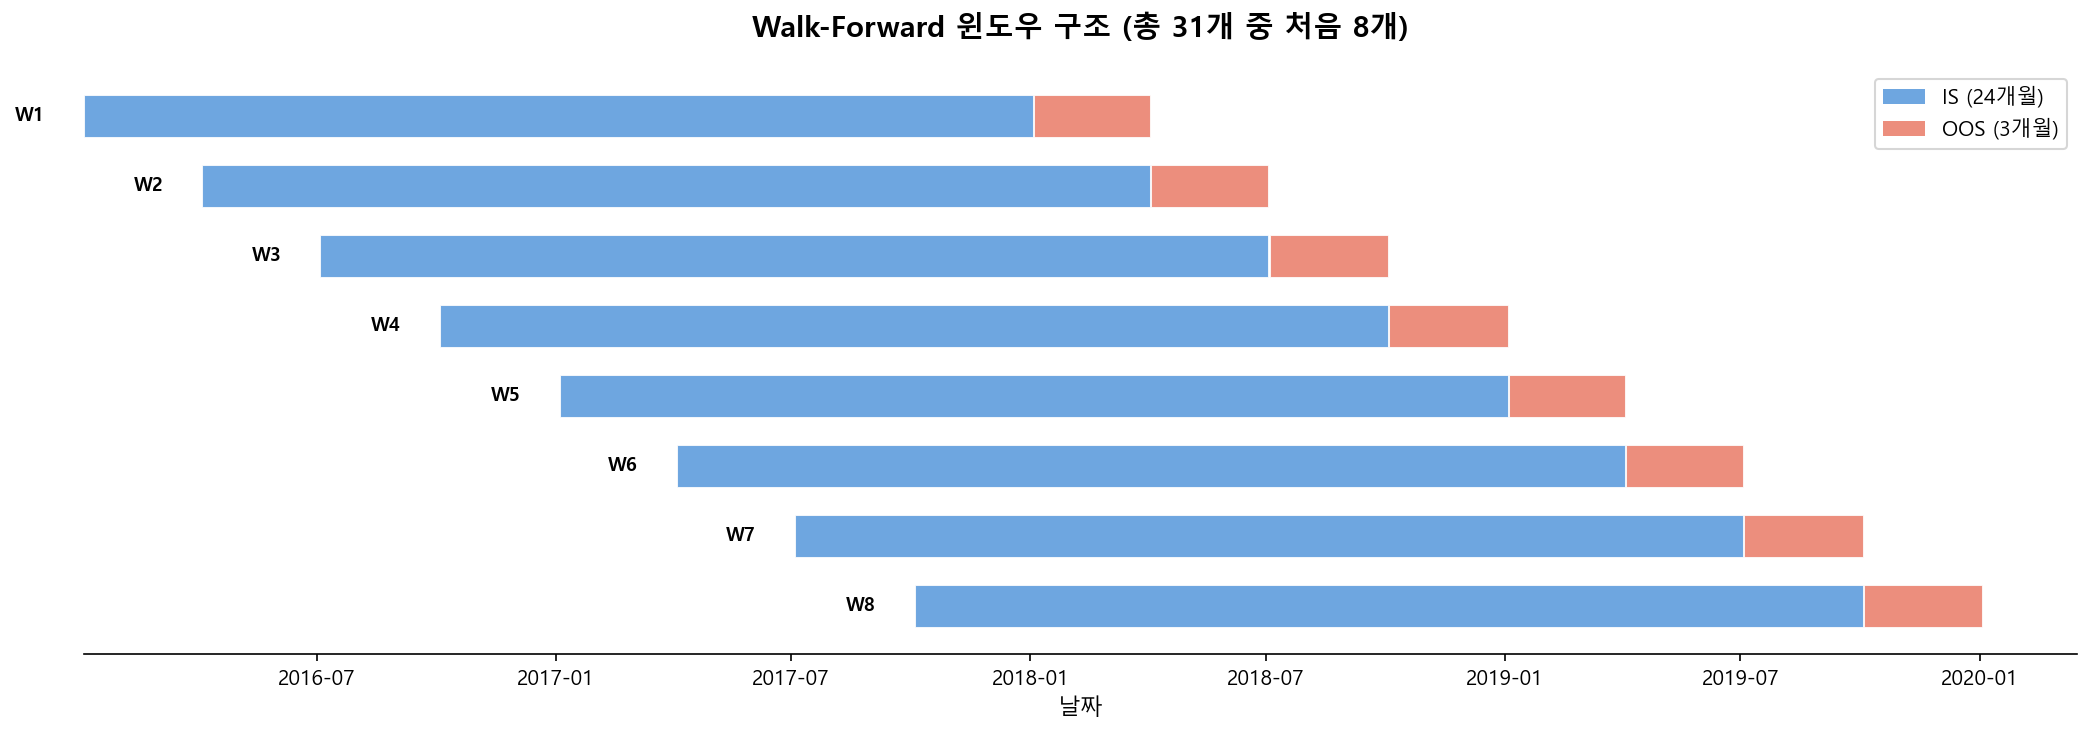

✓ 저장: images/step4_01_wf_structure.png


In [3]:
# ── Walk-Forward 윈도우 구조 시각화 ──
fig, ax = plt.subplots(figsize=(14, 5))

n_show = min(8, len(windows))
colors_is = '#4A90D9'
colors_oos = '#E8725C'

for i in range(n_show):
    w = windows[i]
    # IS 바
    ax.barh(n_show - i, (w['is_end'] - w['is_start']).days, left=w['is_start'],
            height=0.6, color=colors_is, alpha=0.8, edgecolor='white', linewidth=0.5)
    # OOS 바
    ax.barh(n_show - i, (w['oos_end'] - w['oos_start']).days, left=w['oos_start'],
            height=0.6, color=colors_oos, alpha=0.8, edgecolor='white', linewidth=0.5)
    # 윈도우 번호
    ax.text(w['is_start'] - pd.Timedelta(days=30), n_show - i,
            f'W{i+1}', ha='right', va='center', fontsize=9, fontweight='bold')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_is, alpha=0.8, label=f'IS ({IS_MONTHS}개월)'),
                   Patch(facecolor=colors_oos, alpha=0.8, label=f'OOS ({OOS_MONTHS}개월)')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_yticks([])
ax.set_xlabel('날짜', fontsize=11)
ax.set_title(f'Walk-Forward 윈도우 구조 (총 {len(windows)}개 중 처음 {n_show}개)',
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(IMG / 'step4_01_wf_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: images/step4_01_wf_structure.png")

## 4-2. 백테스팅 엔진

각 Walk-Forward 윈도우에서:
1. **IS 구간**: Ledoit-Wolf 공분산 추정 + Mean-Variance 최적화로 가중치 산출
2. **OOS 구간**: IS에서 구한 고정 가중치로 일별 수익률 계산
3. 리밸런싱 시점에서 턴오버 기반 거래비용(편도 15bps) 차감

In [4]:
# ── 백테스팅 엔진 (2026-04-19 업데이트: Option Y) ──
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

def optimize_mv_weights(mu, cov, profile, n_assets, tickers):
    """
    Mean-Variance 최적화 (프로파일 제약 반영)

    목적함수: min  gamma/2 * w'Σw - w'μ
    제약: sum(w) = 1, w >= 0, equity <= max_equity, bond >= min_bond

    주의 (2026-04 업데이트):
    - max_mdd는 프로파일 "설계 목표"이지 직접 제약 아님
    - μ 추정 오차로 corner solution 가능 → 일부 프로파일에서 EW보다 낮은 Sharpe
    - Step 7의 alert 기반 동적 리밸런싱이 이 한계 보완
    """
    gamma = profile['gamma']
    max_eq = profile['max_equity']
    min_bd = profile['min_bond']

    eq_idx = [i for i, t in enumerate(tickers) if t in EQUITY_ALL]
    bd_idx = [i for i, t in enumerate(tickers) if t in BOND]

    def objective(w):
        ret = w @ mu
        risk = w @ cov @ w
        return -(ret - gamma / 2 * risk)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    if len(eq_idx) > 0:
        constraints.append({'type': 'ineq', 'fun': lambda w: max_eq - np.sum(w[eq_idx])})
    if len(bd_idx) > 0:
        constraints.append({'type': 'ineq', 'fun': lambda w: np.sum(w[bd_idx]) - min_bd})

    bounds = [(0, 1)] * n_assets
    w0 = np.ones(n_assets) / n_assets

    result = minimize(objective, w0, method='SLSQP',
                      bounds=bounds, constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-12})

    if result.success:
        w_opt = np.maximum(result.x, 0)
        w_opt /= w_opt.sum()
        return w_opt
    else:
        return np.ones(n_assets) / n_assets


def backtest_walk_forward(profile_name, profile, log_ret, simple_ret, windows, tickers):
    """
    Walk-Forward 백테스트 (2026-04-19 업데이트):
    - IS 최적화: log_ret 사용 (Ledoit-Wolf·μ 추정에 적합)
    - OOS P&L: simple_ret 사용 (가중합·복리 정확)
    - 턴오버: OOS drift 반영 (prev target → 실제 drifted 비중 기준)
    """
    daily_records = []
    prev_weights = None
    prev_simple_oos = None
    total_turnover = 0
    rebalance_count = 0

    for i, w in enumerate(windows):
        is_ret = log_ret.loc[w['is_start']:w['is_end']]
        oos_simple = simple_ret.loc[w['oos_start']:w['oos_end']]

        if len(is_ret) < 100 or len(oos_simple) < 5:
            continue

        # ── IS 최적화 (로그 수익률) ──
        mu_is = is_ret.mean().values * 252
        lw = LedoitWolf().fit(is_ret.values)
        cov_is = lw.covariance_ * 252
        weights = optimize_mv_weights(mu_is, cov_is, profile, len(tickers), tickers)

        # ── 턴오버 (drift 반영) ──
        if prev_weights is not None and prev_simple_oos is not None:
            cum_per_asset = (1 + prev_simple_oos).prod().values
            drifted_raw = prev_weights * cum_per_asset
            drifted_weights = drifted_raw / drifted_raw.sum()
            turnover = np.sum(np.abs(weights - drifted_weights))
        else:
            turnover = 1.0

        total_turnover += turnover
        rebalance_cost = turnover * TOTAL_COST
        rebalance_count += 1

        # ── OOS 적용 (단순 수익률 기반) ──
        first_day = True
        for date, row in oos_simple.iterrows():
            port_ret = np.sum(weights * row.values)
            if first_day:
                port_ret -= rebalance_cost
                first_day = False
            daily_records.append({'date': date, 'return': port_ret, 'window': i + 1})

        prev_weights = weights.copy()
        prev_simple_oos = oos_simple

    result_df = pd.DataFrame(daily_records).set_index('date')
    info = {
        'total_turnover': total_turnover,
        'rebalance_count': rebalance_count,
        'avg_turnover': total_turnover / max(rebalance_count, 1)
    }
    return result_df, info


def backtest_equal_weight(simple_ret, windows, n_assets):
    """1/N Equal Weight 벤치마크 (단순 수익률)"""
    daily_records = []
    w_eq = np.ones(n_assets) / n_assets

    for i, w in enumerate(windows):
        oos_ret = simple_ret.loc[w['oos_start']:w['oos_end']]
        if len(oos_ret) < 5:
            continue
        first_day = True
        for date, row in oos_ret.iterrows():
            port_ret = np.sum(w_eq * row.values)
            if first_day:
                port_ret -= TOTAL_COST
                first_day = False
            daily_records.append({'date': date, 'return': port_ret})

    return pd.DataFrame(daily_records).set_index('date')


def backtest_single_asset(simple_ret, windows, ticker):
    """단일 자산 벤치마크 (buy-and-hold)"""
    daily_records = []
    col_idx = list(simple_ret.columns).index(ticker)

    for i, w in enumerate(windows):
        oos_ret = simple_ret.loc[w['oos_start']:w['oos_end']]
        if len(oos_ret) < 5:
            continue
        for date, row in oos_ret.iterrows():
            daily_records.append({'date': date, 'return': row.values[col_idx]})

    return pd.DataFrame(daily_records).set_index('date')


def backtest_60_40(simple_ret, windows):
    """60/40 벤치마크 (SPY 60% / AGG 40%)"""
    daily_records = []
    spy_idx = list(simple_ret.columns).index('SPY')
    agg_idx = list(simple_ret.columns).index('AGG')

    for i, w in enumerate(windows):
        oos_ret = simple_ret.loc[w['oos_start']:w['oos_end']]
        if len(oos_ret) < 5:
            continue
        first_day = True
        for date, row in oos_ret.iterrows():
            port_ret = 0.6 * row.values[spy_idx] + 0.4 * row.values[agg_idx]
            if first_day:
                port_ret -= TOTAL_COST
                first_day = False
            daily_records.append({'date': date, 'return': port_ret})

    return pd.DataFrame(daily_records).set_index('date')


print('백테스팅 엔진 정의 완료 (Option Y 적용)')
print(f'  - IS 최적화: 로그 수익률 (Ledoit-Wolf, μ 추정)')
print(f'  - OOS P&L: 단순 수익률 (가중합·복리 정확)')
print(f'  - 턴오버: drift 반영 (prev target → drifted 실제)')
print(f'  - 거래비용: 편도 {TOTAL_COST*10000:.0f}bps')


백테스팅 엔진 정의 완료 (Option Y 적용)
  - IS 최적화: 로그 수익률 (Ledoit-Wolf, μ 추정)
  - OOS P&L: 단순 수익률 (가중합·복리 정확)
  - 턴오버: drift 반영 (prev target → drifted 실제)
  - 거래비용: 편도 15bps


In [5]:
# ── 4개 프로파일 + 벤치마크 백테스트 실행 ──
import time

backtest_results = {}
backtest_info = {}

# 1) 4개 프로파일 MV 전략
for pname in PROFILE_NAMES:
    t0 = time.time()
    result, info = backtest_walk_forward(
        pname, PROFILE_MAP[pname], log_returns, simple_returns, windows, ALL_TICKERS
    )
    elapsed = time.time() - t0
    backtest_results[pname] = result['return']
    backtest_info[pname] = info
    print(f'  [{pname}] {elapsed:.1f}초 | 윈도우 {info["rebalance_count"]}개 | '
          f'평균 턴오버 {info["avg_turnover"]:.2%} | OOS 일수 {len(result)}일')

# 2) 벤치마크
print('\n벤치마크:')
ew_result = backtest_equal_weight(simple_returns, windows, len(ALL_TICKERS))
backtest_results['EW (1/30)'] = ew_result['return']
print(f'  [EW 1/30] OOS 일수 {len(ew_result)}일')

spy_result = backtest_single_asset(simple_returns, windows, 'SPY')
backtest_results['SPY 100%'] = spy_result['return']
print(f'  [SPY 100%] OOS 일수 {len(spy_result)}일')

mix_result = backtest_60_40(simple_returns, windows)
backtest_results['60/40'] = mix_result['return']
print(f'  [60/40] OOS 일수 {len(mix_result)}일')

print(f'\n총 {len(backtest_results)}개 전략 백테스트 완료')


  [보수형] 1.0초 | 윈도우 31개 | 평균 턴오버 62.16% | OOS 일수 1948일


  [중립형] 0.8초 | 윈도우 31개 | 평균 턴오버 68.19% | OOS 일수 1948일


  [적극형] 0.7초 | 윈도우 31개 | 평균 턴오버 63.09% | OOS 일수 1948일


  [공격형] 0.6초 | 윈도우 31개 | 평균 턴오버 54.87% | OOS 일수 1948일

벤치마크:
  [EW 1/30] OOS 일수 1948일
  [SPY 100%] OOS 일수 1948일
  [60/40] OOS 일수 1948일

총 7개 전략 백테스트 완료


## 4-3. 성과 메트릭

주요 성과 지표를 계산합니다:
- **연율 수익률 / 변동성**: 전략의 수익-위험 특성
- **Sharpe Ratio**: 위험 대비 초과수익 (무위험 수익률 = 0 가정)
- **Sortino Ratio**: 하방위험만 고려한 위험조정 수익
- **MDD (Maximum Drawdown)**: 최대 낙폭
- **Calmar Ratio**: 연율 수익률 / |MDD|

In [6]:
# ── 성과 메트릭 계산 ──

def compute_metrics(daily_returns, name=''):
    """일별 수익률 시리즈로부터 주요 성과 메트릭 산출"""
    r = daily_returns.dropna()
    n_days = len(r)
    
    # 누적 수익률
    cum = (1 + r).cumprod()
    total_return = cum.iloc[-1] - 1
    
    # 연율화
    n_years = n_days / 252
    ann_return = (1 + total_return) ** (1 / n_years) - 1
    ann_vol = r.std() * np.sqrt(252)
    
    # Sharpe (rf = 0)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    
    # Sortino
    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else 1e-10
    sortino = ann_return / downside_vol
    
    # MDD
    peak = cum.cummax()
    dd = (cum - peak) / peak
    mdd = dd.min()
    
    # Calmar
    calmar = ann_return / abs(mdd) if abs(mdd) > 0 else 0
    
    return {
        'name': name,
        '누적수익률': total_return,
        '연율수익률': ann_return,
        '연율변동성': ann_vol,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'MDD': mdd,
        'Calmar': calmar,
        'OOS일수': n_days
    }


# 전체 메트릭 계산
metrics_list = []
for strategy_name, rets in backtest_results.items():
    m = compute_metrics(rets, strategy_name)
    metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list).set_index('name')

# 보기 좋게 포맷팅
fmt_df = metrics_df.copy()
for col in ['누적수익률', '연율수익률', '연율변동성', 'MDD']:
    fmt_df[col] = fmt_df[col].map('{:.2%}'.format)
for col in ['Sharpe', 'Sortino', 'Calmar']:
    fmt_df[col] = fmt_df[col].map('{:.3f}'.format)
fmt_df['OOS일수'] = fmt_df['OOS일수'].astype(int)

print("=" * 100)
print("Walk-Forward 백테스트 성과 비교표")
print("=" * 100)
print(fmt_df.to_string())
print("=" * 100)

Walk-Forward 백테스트 성과 비교표
             누적수익률   연율수익률   연율변동성 Sharpe Sortino      MDD Calmar  OOS일수
name                                                                    
보수형        120.19%  10.75%  13.38%  0.804   1.076  -20.31%  0.529   1948
중립형        177.23%  14.10%  19.95%  0.707   0.946  -28.16%  0.501   1948
적극형        271.49%  18.50%  24.57%  0.753   1.015  -30.87%  0.599   1948
공격형        366.82%  22.06%  27.37%  0.806   1.092  -32.24%  0.684   1948
EW (1/30)  135.13%  11.69%  15.27%  0.766   0.921  -28.09%  0.416   1948
SPY 100%   179.52%  14.22%  19.64%  0.724   0.883  -33.72%  0.422   1948
60/40       93.31%   8.90%  12.32%  0.723   0.883  -21.72%  0.410   1948


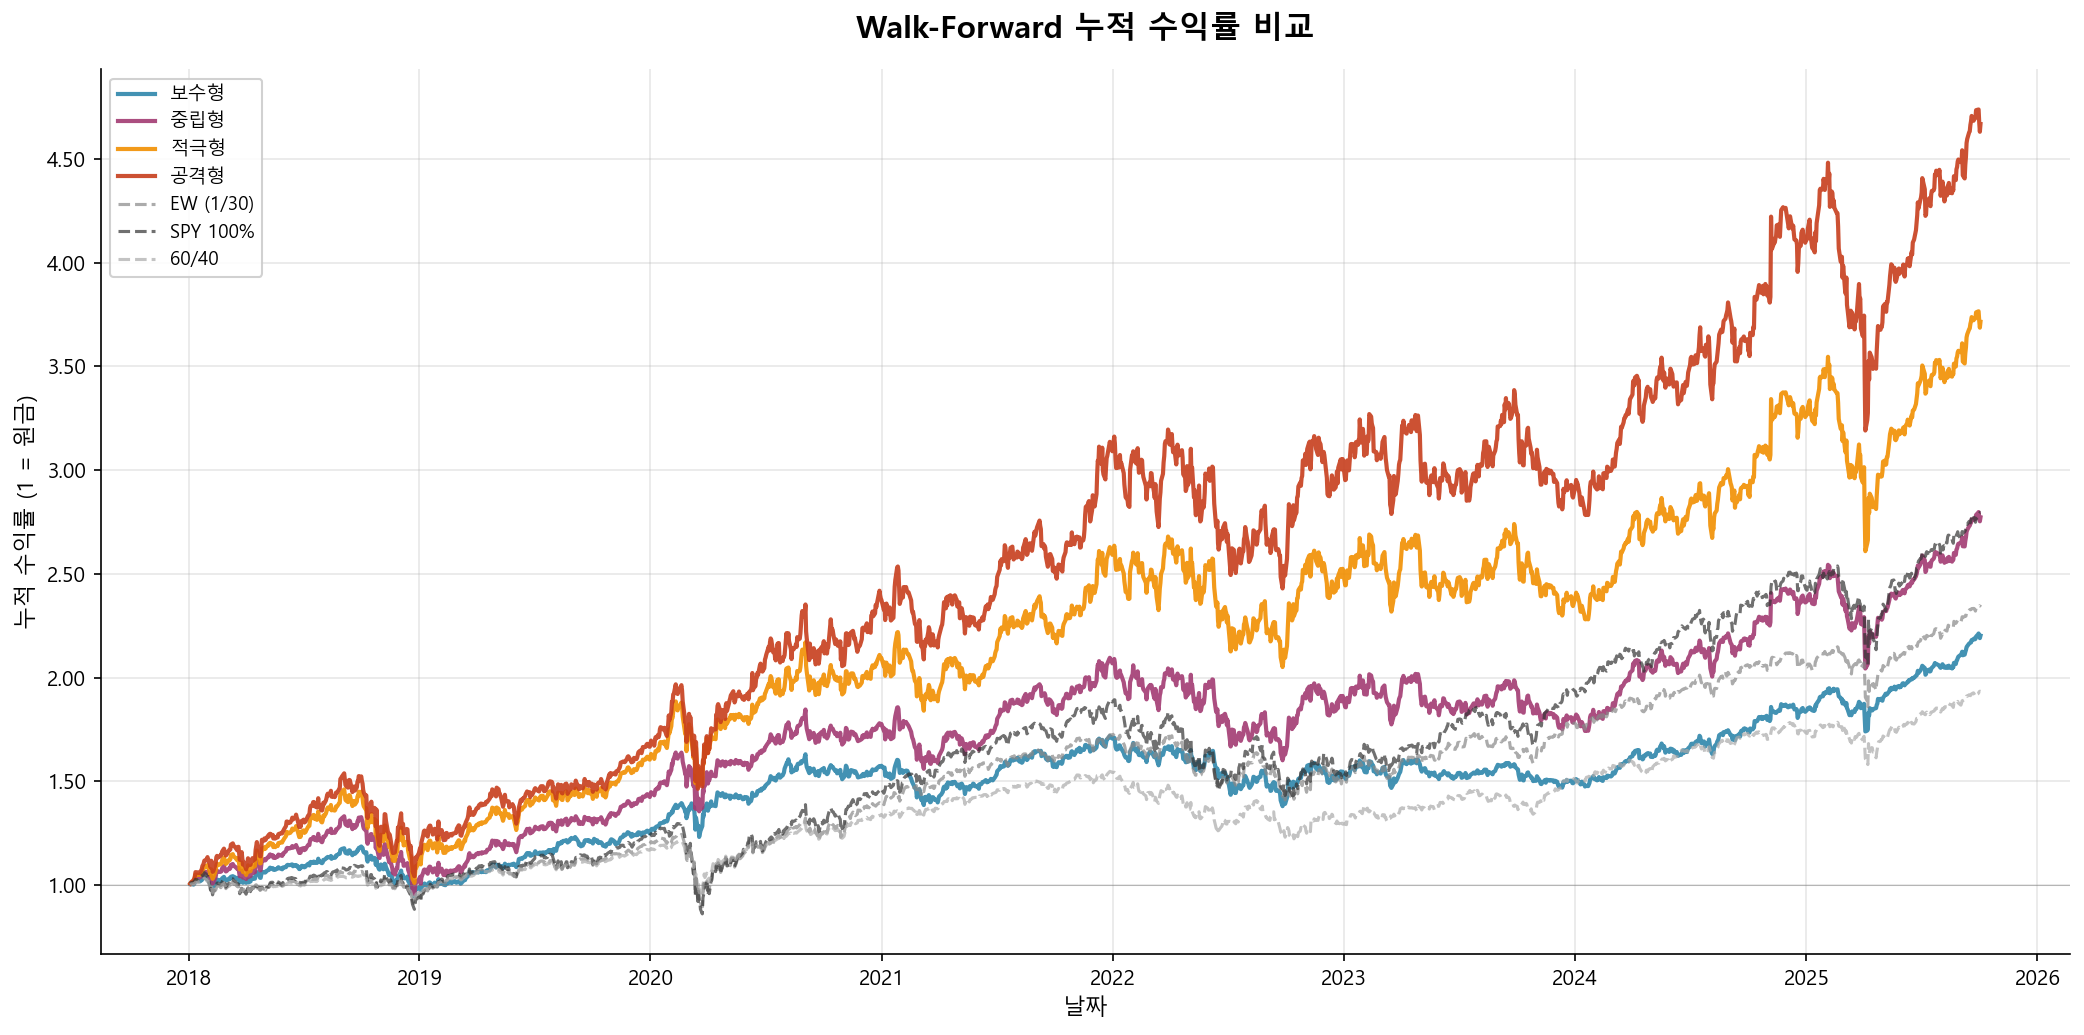

✓ 저장: images/step4_02_cumulative_returns.png


In [7]:
# ── 누적 수익률 시각화 ──
fig, ax = plt.subplots(figsize=(14, 7))

# 색상 팔레트
profile_colors = {
    PROFILE_NAMES[0]: '#2E86AB',  # 보수형
    PROFILE_NAMES[1]: '#A23B72',  # 중립형
    PROFILE_NAMES[2]: '#F18F01',  # 적극형
    PROFILE_NAMES[3]: '#C73E1D',  # 공격형
}
bench_colors = {
    'EW (1/30)': '#888888',
    'SPY 100%': '#333333',
    '60/40': '#AAAAAA',
}

for name, rets in backtest_results.items():
    cum = (1 + rets).cumprod()
    if name in profile_colors:
        ax.plot(cum.index, cum.values, label=name,
                color=profile_colors[name], linewidth=2.0, alpha=0.9)
    else:
        ax.plot(cum.index, cum.values, label=name,
                color=bench_colors.get(name, '#666666'),
                linewidth=1.5, linestyle='--', alpha=0.7)

ax.axhline(y=1, color='gray', linewidth=0.5, alpha=0.5)
ax.set_title('Walk-Forward 누적 수익률 비교', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('날짜', fontsize=11)
ax.set_ylabel('누적 수익률 (1 = 원금)', fontsize=11)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(IMG / 'step4_02_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 저장: images/step4_02_cumulative_returns.png")

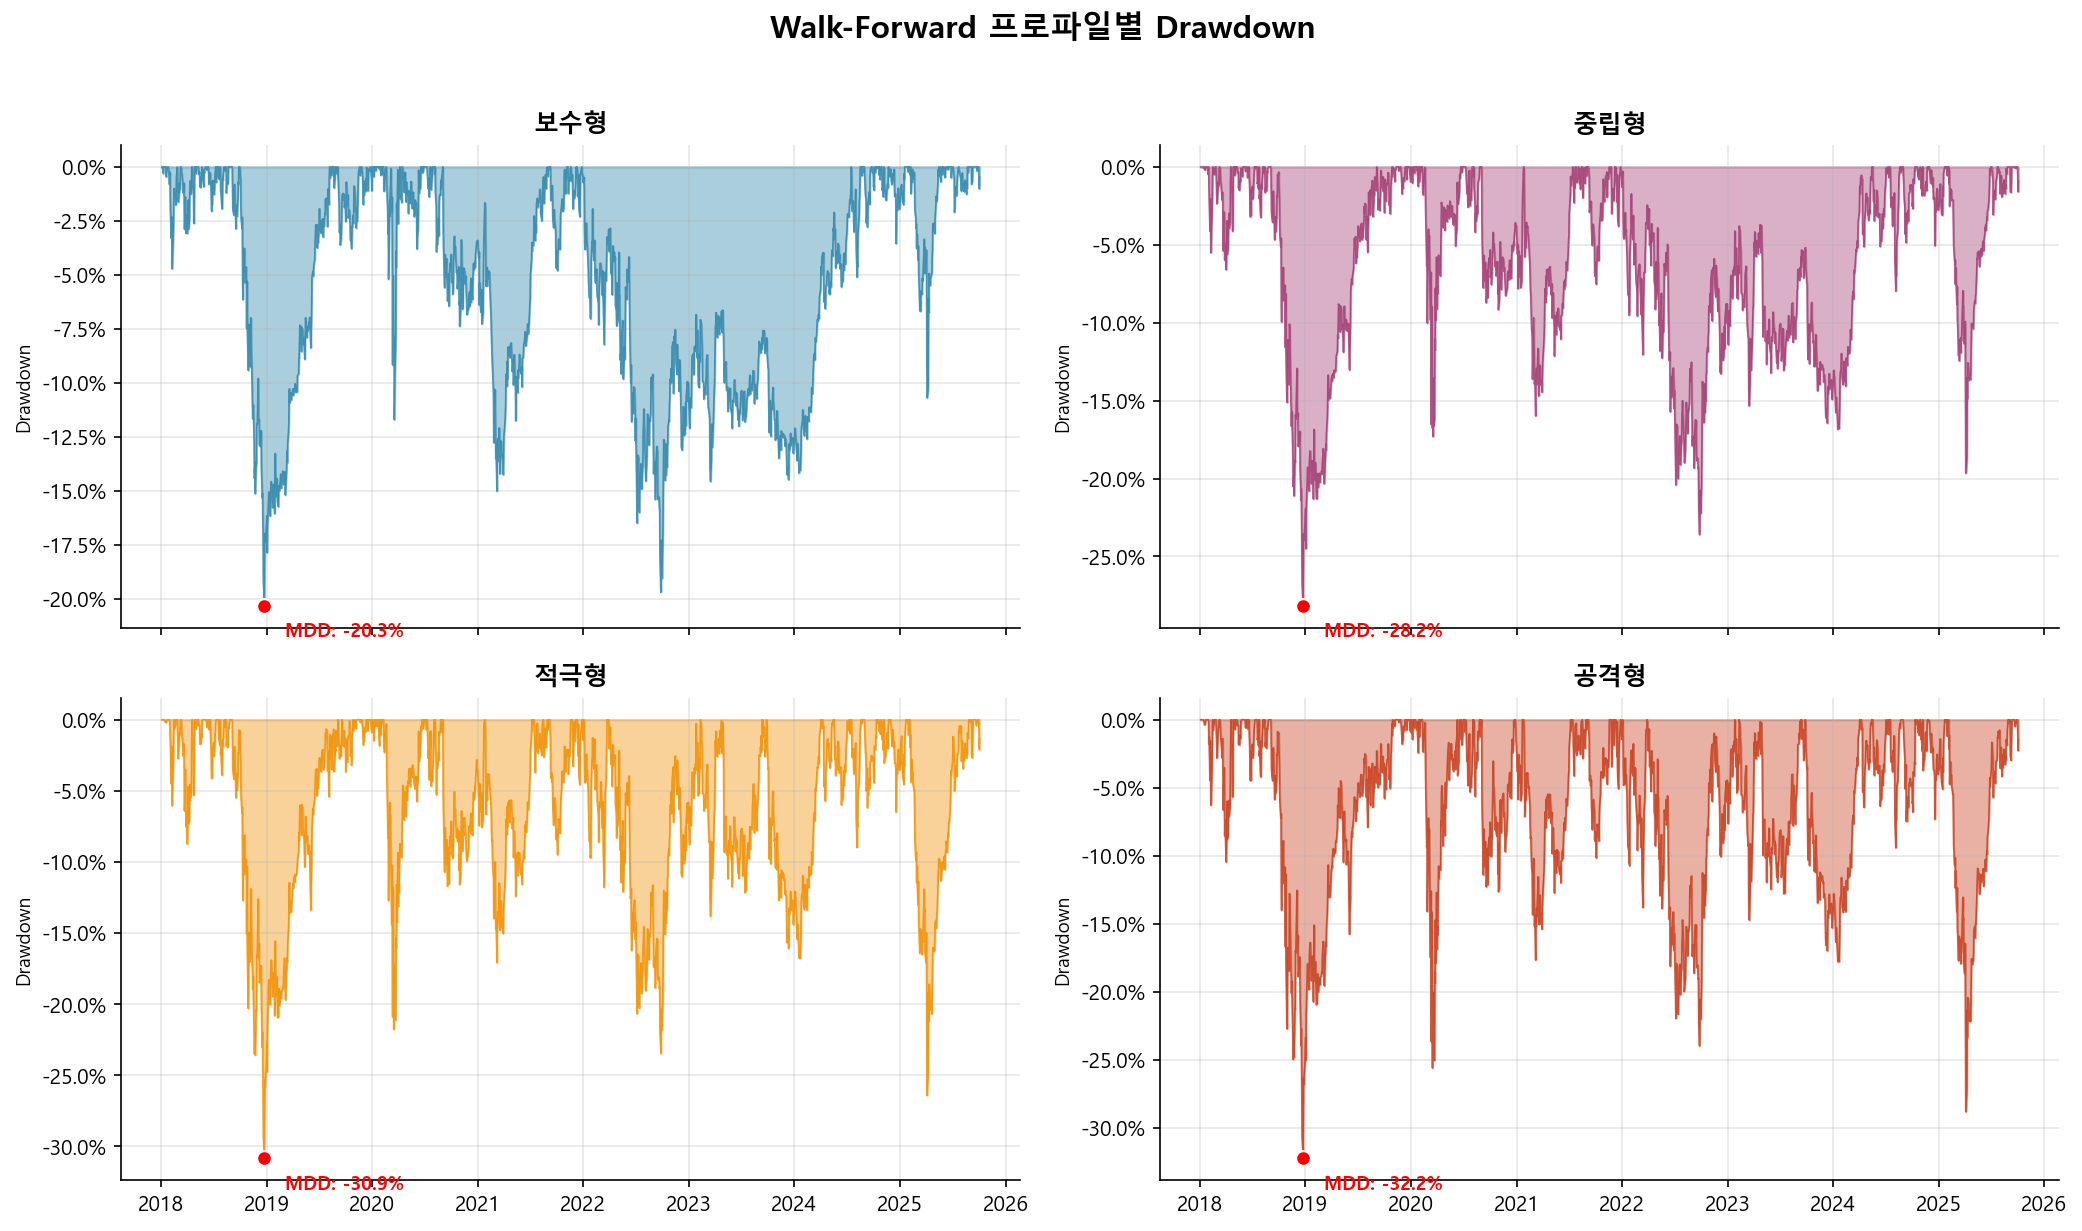

✓ 저장: images/step4_03_drawdown.png


In [8]:
# ── Drawdown 타임라인 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for idx, pname in enumerate(PROFILE_NAMES):
    ax = axes[idx // 2][idx % 2]
    rets = backtest_results[pname]
    cum = (1 + rets).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    
    color = list(profile_colors.values())[idx]
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.4)
    ax.plot(dd.index, dd.values, color=color, linewidth=0.8, alpha=0.8)
    
    # MDD 포인트
    mdd_val = dd.min()
    mdd_date = dd.idxmin()
    ax.scatter(mdd_date, mdd_val, color='red', s=50, zorder=5, edgecolors='white')
    ax.annotate(f'MDD: {mdd_val:.1%}', xy=(mdd_date, mdd_val),
                xytext=(10, -15), textcoords='offset points',
                fontsize=9, fontweight='bold', color='red')
    
    ax.set_title(f'{pname}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Drawdown', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Walk-Forward 프로파일별 Drawdown', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG / 'step4_03_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 저장: images/step4_03_drawdown.png")

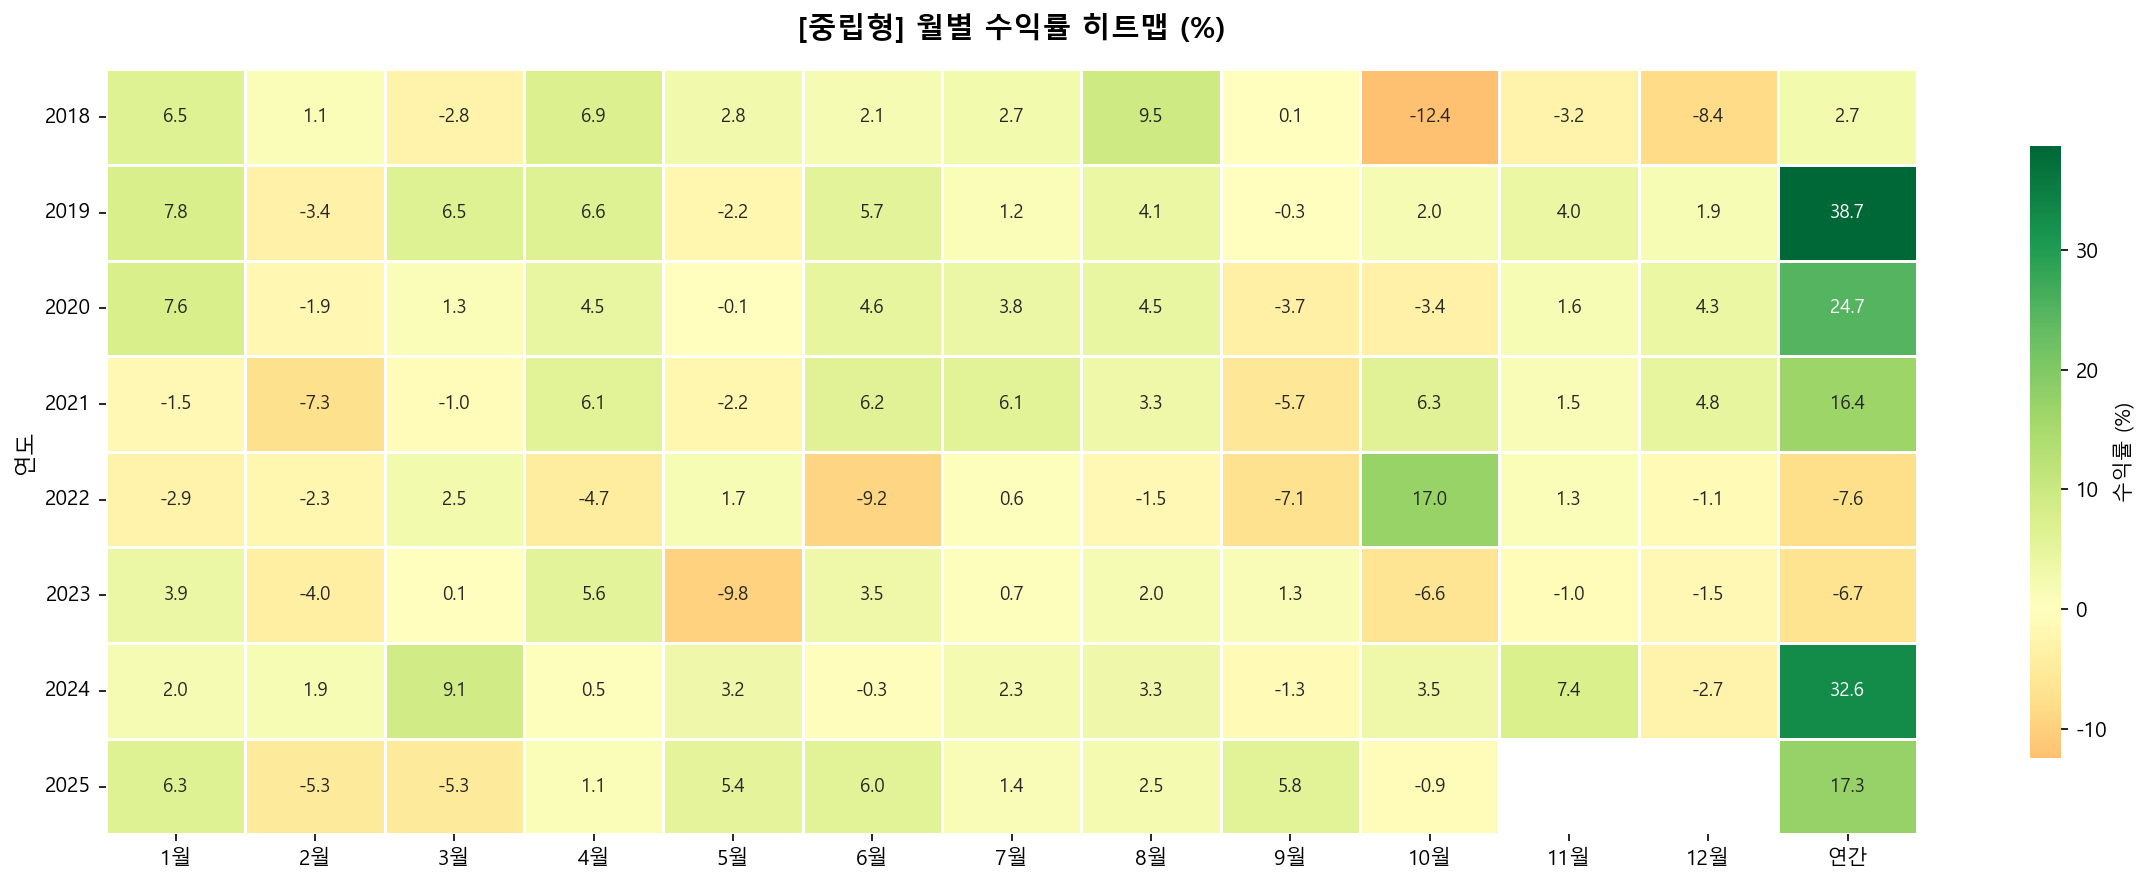

✓ 저장: images/step4_04_monthly_heatmap.png (프로파일: 중립형)


In [9]:
# ── 월별 수익률 히트맵 (중립형 프로파일) ──
moderate_name = PROFILE_NAMES[1]  # 중립형
moderate_rets = backtest_results[moderate_name]

# 월별 수익률 집계
monthly = moderate_rets.groupby([moderate_rets.index.year, moderate_rets.index.month]).apply(
    lambda x: (1 + x).prod() - 1
)
monthly.index = pd.MultiIndex.from_tuples(monthly.index, names=['Year', 'Month'])
monthly_pivot = monthly.unstack(level='Month')
monthly_pivot.columns = ['1월','2월','3월','4월','5월','6월',
                          '7월','8월','9월','10월','11월','12월']

# 연간 수익률 열 추가
yearly_return = moderate_rets.groupby(moderate_rets.index.year).apply(
    lambda x: (1 + x).prod() - 1
)
# monthly_pivot에 있는 연도만 매칭
monthly_pivot['연간'] = yearly_return.reindex(monthly_pivot.index).values

fig, ax = plt.subplots(figsize=(16, 6))

# NaN을 회색으로 표시하기 위해 마스크 설정
mask = monthly_pivot.isna()

sns.heatmap(monthly_pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': '수익률 (%)', 'shrink': 0.8},
            mask=mask, ax=ax,
            annot_kws={'size': 9})

ax.set_title(f'[{moderate_name}] 월별 수익률 히트맵 (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('연도', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(IMG / 'step4_04_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: images/step4_04_monthly_heatmap.png (프로파일: {moderate_name})")

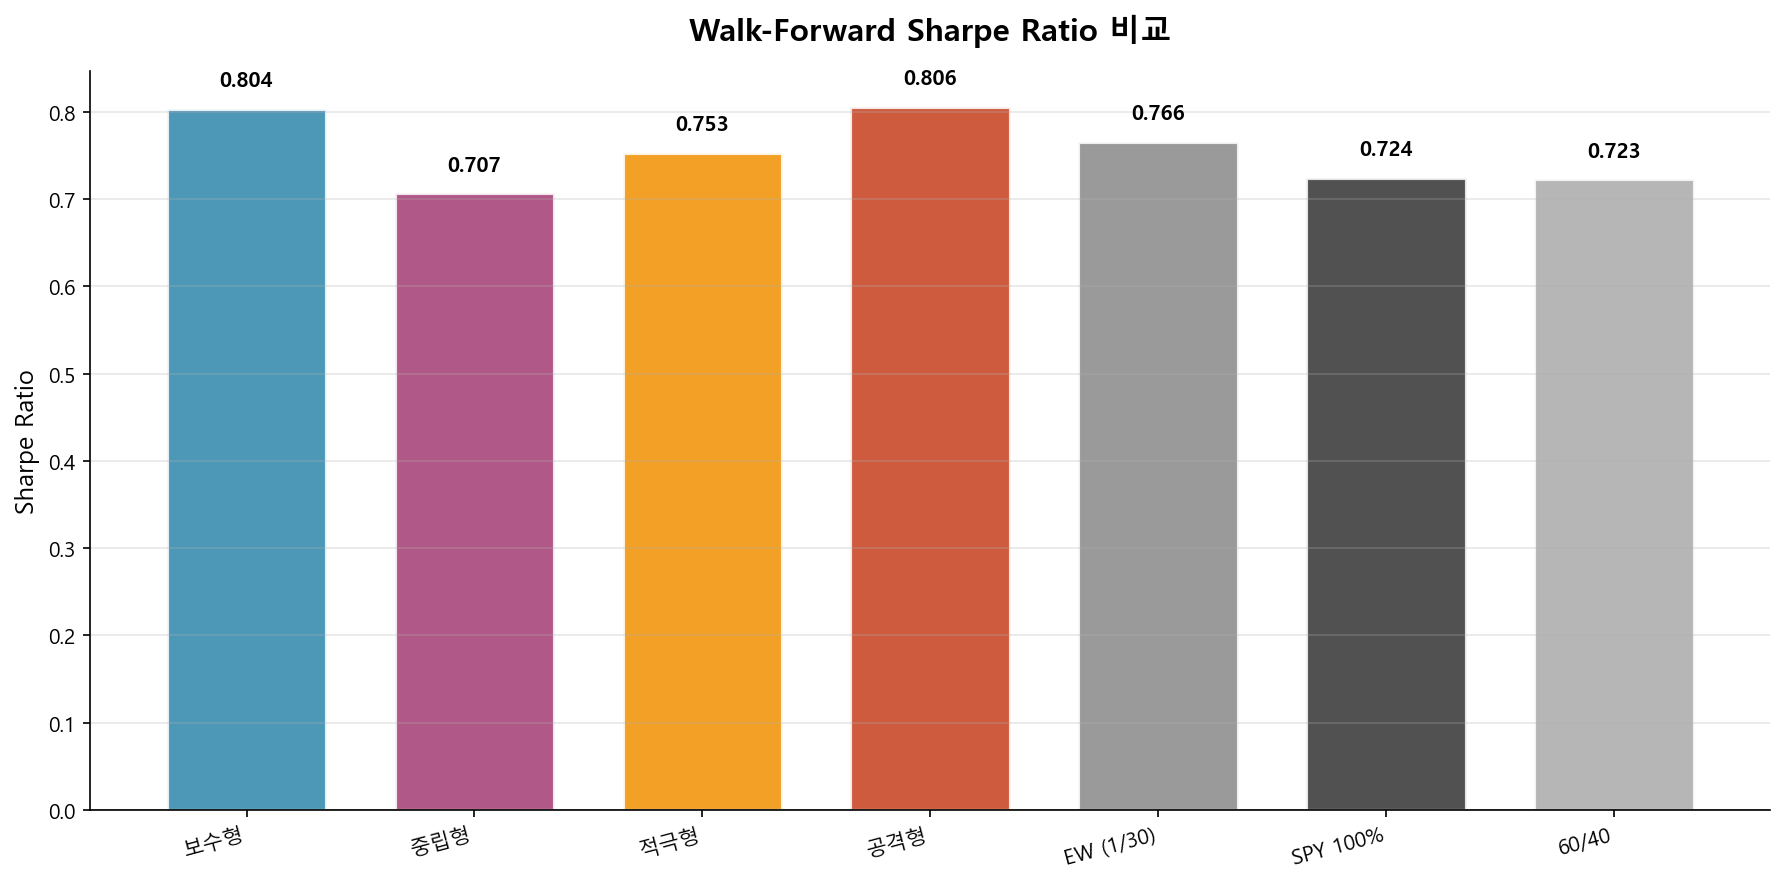

✓ 저장: images/step4_05_sharpe_comparison.png


In [10]:
# ── Sharpe Ratio 비교 바 차트 ──
fig, ax = plt.subplots(figsize=(12, 6))

all_names = list(backtest_results.keys())
sharpe_vals = [metrics_df.loc[n, 'Sharpe'] for n in all_names]

# 색상 지정
bar_colors = []
for n in all_names:
    if n in profile_colors:
        bar_colors.append(profile_colors[n])
    else:
        bar_colors.append(bench_colors.get(n, '#999999'))

bars = ax.bar(range(len(all_names)), sharpe_vals, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=1.5, width=0.7)

# 값 표시
for bar, val in zip(bars, sharpe_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(all_names)))
ax.set_xticklabels(all_names, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Walk-Forward Sharpe Ratio 비교', fontsize=15, fontweight='bold', pad=15)
ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax.grid(True, axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(IMG / 'step4_05_sharpe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 저장: images/step4_05_sharpe_comparison.png")

In [11]:
# ── 결과 저장 ──

# 1) 백테스트 일별 수익률 저장
bt_df = pd.DataFrame(backtest_results)
bt_df.index.name = 'Date'
bt_df.to_csv(DATA / 'backtest_results.csv')
print(f"✓ 저장: data/backtest_results.csv ({bt_df.shape[0]}행 × {bt_df.shape[1]}열)")

# 2) 메트릭 저장
metrics_df.index.name = 'strategy'
metrics_df.to_csv(DATA / 'wf_metrics.csv')
print(f"✓ 저장: data/wf_metrics.csv ({metrics_df.shape[0]}개 전략)")

# 최종 요약
print(f"\n{'='*60}")
print(f"Step 4 Walk-Forward 백테스팅 완료")
print(f"{'='*60}")
print(f"  윈도우: {len(windows)}개 (IS={IS_MONTHS}M, OOS={OOS_MONTHS}M)")
print(f"  전략: {len(PROFILE_NAMES)}개 프로파일 + 3개 벤치마크")
print(f"  OOS 기간: {bt_df.index.min().strftime('%Y-%m-%d')} ~ {bt_df.index.max().strftime('%Y-%m-%d')}")
print(f"  거래비용: 편도 {TOTAL_COST*10000:.0f}bps")
print(f"  이미지 4장 저장 완료")
print(f"{'='*60}")

✓ 저장: data/backtest_results.csv (1948행 × 7열)
✓ 저장: data/wf_metrics.csv (7개 전략)

Step 4 Walk-Forward 백테스팅 완료
  윈도우: 31개 (IS=24M, OOS=3M)
  전략: 4개 프로파일 + 3개 벤치마크
  OOS 기간: 2018-01-04 ~ 2025-10-03
  거래비용: 편도 15bps
  이미지 4장 저장 완료
